<a href="https://colab.research.google.com/github/muhammedgmbsg/cross_validation_fruit_classification/blob/main/10fold-fruit-classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.model_selection import KFold
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive

In [ ]:
drive.mount('/content/drive')
LOCAL_PATH = '/content/fruits_dataset'
if not os.path.exists(LOCAL_PATH):
    os.system(f'cp -r /content/drive/MyDrive/fruits {LOCAL_PATH}')

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
NUM_CLASSES = 10
EPOCHS = 40

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def get_dataset(path):
    file_paths, labels = [], []
    for folder in ['train', 'test']:
        curr = os.path.join(path, folder)
        if not os.path.exists(curr): continue
        classes = sorted([d for d in os.listdir(curr) if os.path.isdir(os.path.join(curr, d))])
        for cls in classes:
            cls_dir = os.path.join(curr, cls)
            for img in os.listdir(cls_dir):
                file_paths.append(os.path.join(cls_dir, img))
                labels.append(cls)
    return pd.DataFrame({'filename': file_paths, 'class': labels}), classes

In [ ]:
def create_optimized_model():

    model = models.Sequential([
        Input(shape=(128, 128, 3)),

        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.6),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0007),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
df, categories = get_dataset(LOCAL_PATH)
kf = KFold(n_splits=10, shuffle=True, random_state=42)
all_fold_accuracies = []

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)

for i, (train_idx, val_idx) in enumerate(kf.split(df)):
    tf.keras.backend.clear_session()
    print(f"\n--- FOLD {i+1} / 10 Başlatılıyor ---")

    train_gen = train_datagen.flow_from_dataframe(
        df.iloc[train_idx], target_size=(128, 128), batch_size=BATCH_SIZE, class_mode='categorical', verbose=0)

    val_gen = val_datagen.flow_from_dataframe(
        df.iloc[val_idx], target_size=(128, 128), batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False, verbose=0)

    model = create_optimized_model()

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
    ]

    model.fit(train_gen, epochs=EPOCHS, validation_data=val_gen, callbacks=callbacks, verbose=1)

    _, acc = model.evaluate(val_gen, verbose=0)
    print(f"Fold {i+1} Başarı Oranı: %{acc*100:.2f}")
    all_fold_accuracies.append(acc)

print("\n" + "="*35)
print(f"10-Fold Ortalama Doğruluk: %{np.mean(all_fold_accuracies)*100:.2f}")
print(f"Standart Sapma: %{np.std(all_fold_accuracies)*100:.2f}")
print("="*35)


--- FOLD 1 / 10 Başlatılıyor ---
Found 2993 validated image filenames belonging to 10 classes.
Found 333 validated image filenames belonging to 10 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 28s 221ms/step - accuracy: 0.2406 - loss: 2.1755 - val_accuracy: 0.0661 - val_loss: 2.4526 - learning_rate: 7.0000e-04
Epoch 2/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 163ms/step - accuracy: 0.3947 - loss: 1.6684 - val_accuracy: 0.0781 - val_loss: 2.6286 - learning_rate: 7.0000e-04
Epoch 3/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 164ms/step - accuracy: 0.4904 - loss: 1.4869 - val_accuracy: 0.0901 - val_loss: 2.9831 - learning_rate: 7.0000e-04
Epoch 4/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 164ms/step - accuracy: 0.5317 - loss: 1.3741 - val_accuracy: 0.1652 - val_loss: 2.7623 - learning_rate: 7.0000e-04
Epoch 5/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 183ms/step - accuracy: 0.5528 - loss: 1.2890 - val_accuracy: 0.2913 - val_loss: 2.1603 - learning_rate: 7.0000e-04
Epoch 6/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 161ms/step - accuracy: 0.5887 - loss: 1.1964 - val_accuracy: 0.3333 - val_loss: 1.9367 - learning_rate: 7.0000e-04
Epoch 7/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 161ms/step - acc

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 24s 196ms/step - accuracy: 0.2441 - loss: 2.1474 - val_accuracy: 0.0991 - val_loss: 2.4351 - learning_rate: 7.0000e-04
Epoch 2/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 159ms/step - accuracy: 0.4146 - loss: 1.6306 - val_accuracy: 0.1171 - val_loss: 2.6509 - learning_rate: 7.0000e-04
Epoch 3/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 157ms/step - accuracy: 0.4807 - loss: 1.5071 - val_accuracy: 0.1171 - val_loss: 2.8296 - learning_rate: 7.0000e-04
Epoch 4/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 158ms/step - accuracy: 0.5247 - loss: 1.3515 - val_accuracy: 0.1892 - val_loss: 2.6437 - learning_rate: 7.0000e-04
Epoch 5/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 157ms/step - accuracy: 0.5608 - loss: 1.2630 - val_accuracy: 0.3033 - val_loss: 2.0027 - learning_rate: 7.0000e-04
Epoch 6/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 164ms/step - accuracy: 0.5732 - loss: 1.2167 - val_accuracy: 0.4444 - val_loss: 1.5317 - learning_rate: 7.0000e-04
Epoch 7/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 161ms/step - acc

...

Epoch 1/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 23s 195ms/step - accuracy: 0.2189 - loss: 2.1858 - val_accuracy: 0.1054 - val_loss: 2.3324 - learning_rate: 7.0000e-04
Epoch 2/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 16s 165ms/step - accuracy: 0.4118 - loss: 1.6436 - val_accuracy: 0.1145 - val_loss: 2.5729 - learning_rate: 7.0000e-04
Epoch 3/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 161ms/step - accuracy: 0.4798 - loss: 1.4830 - val_accuracy: 0.1777 - val_loss: 2.8016 - learning_rate: 7.0000e-04
Epoch 4/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 16s 166ms/step - accuracy: 0.5145 - loss: 1.3912 - val_accuracy: 0.1566 - val_loss: 2.5740 - learning_rate: 7.0000e-04
Epoch 5/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.5614 - loss: 1.2703 - val_accuracy: 0.2861 - val_loss: 2.0393 - learning_rate: 7.0000e-04
Epoch 6/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.5617 - loss: 1.2125 - val_accuracy: 0.4970 - val_loss: 1.4152 - learning_rate: 7.0000e-04
Epoch 7/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 158ms/step - acc

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 24s 196ms/step - accuracy: 0.2600 - loss: 2.1083 - val_accuracy: 0.1506 - val_loss: 2.2672 - learning_rate: 7.0000e-04
Epoch 2/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 159ms/step - accuracy: 0.4440 - loss: 1.5693 - val_accuracy: 0.1386 - val_loss: 2.2616 - learning_rate: 7.0000e-04
Epoch 3/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 159ms/step - accuracy: 0.4825 - loss: 1.4299 - val_accuracy: 0.2380 - val_loss: 2.0926 - learning_rate: 7.0000e-04
Epoch 4/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.5647 - loss: 1.2803 - val_accuracy: 0.3193 - val_loss: 1.8863 - learning_rate: 7.0000e-04
Epoch 5/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 164ms/step - accuracy: 0.5789 - loss: 1.2126 - val_accuracy: 0.3976 - val_loss: 1.5931 - learning_rate: 7.0000e-04
Epoch 6/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 16s 164ms/step - accuracy: 0.5828 - loss: 1.1787 - val_accuracy: 0.5542 - val_loss: 1.2904 - learning_rate: 7.0000e-04
Epoch 7/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 16s 164ms/step - acc

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 25s 205ms/step - accuracy: 0.2304 - loss: 2.2140 - val_accuracy: 0.0904 - val_loss: 2.4224 - learning_rate: 7.0000e-04
Epoch 2/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 159ms/step - accuracy: 0.3975 - loss: 1.6647 - val_accuracy: 0.0934 - val_loss: 2.5824 - learning_rate: 7.0000e-04
Epoch 3/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.4724 - loss: 1.4674 - val_accuracy: 0.1355 - val_loss: 2.6157 - learning_rate: 7.0000e-04
Epoch 4/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.5047 - loss: 1.3885 - val_accuracy: 0.1657 - val_loss: 2.4530 - learning_rate: 7.0000e-04
Epoch 5/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 161ms/step - accuracy: 0.5442 - loss: 1.3137 - val_accuracy: 0.2319 - val_loss: 2.0125 - learning_rate: 7.0000e-04
Epoch 6/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 159ms/step - accuracy: 0.5677 - loss: 1.2269 - val_accuracy: 0.4307 - val_loss: 1.5636 - learning_rate: 7.0000e-04
Epoch 7/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 159ms/step - acc

/tmp/ipykernel_1165/63632658.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


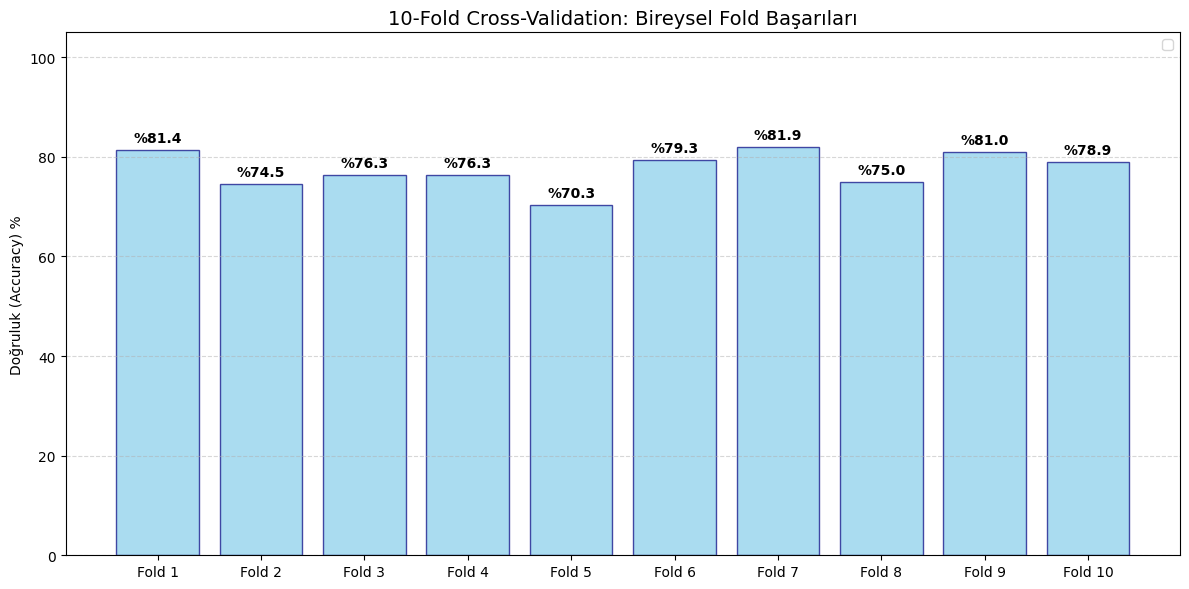


           NİHAİ PERFORMANS RAPORU           
Toplam Fold Sayısı:    10
Doğruluk Başarım:      %81.93 (Fold 7)
Standart Sapma:        %3.51


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

folds = [f"Fold {i+1}" for i in range(len(all_fold_accuracies))]
accuracies = [acc * 100 for acc in all_fold_accuracies]
max_acc = np.max(accuracies)
max_idx = np.argmax(accuracies)

plt.figure(figsize=(12, 6))
colors = ['skyblue'  for i in range(len(accuracies))]
bars = plt.bar(folds, accuracies, color=colors, edgecolor='navy', alpha=0.7)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'%{yval:.1f}', ha='center', va='bottom', fontweight='bold')

plt.title('10-Fold Cross-Validation: Bireysel Fold Başarıları', fontsize=14)
plt.ylabel('Doğruluk (Accuracy) %')
plt.ylim(0, 105)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n" + "="*45)
print("           NİHAİ PERFORMANS RAPORU           ")
print("="*45)
print(f"Toplam Fold Sayısı:    {len(all_fold_accuracies)}")
print(f"Doğruluk Başarım:      %{max_acc:.2f} (Fold {max_idx + 1})")
print(f"Standart Sapma:        %{np.std(accuracies):.2f}")
print("="*45)

